# ContractAI Guardian — Demo Notebook

**AI-Powered Contract Intelligence Platform**

This notebook demonstrates the core AI capabilities:
1. Risk Scoring Algorithm (multi-dimensional weighted scoring)
2. Explainable AI (SHAP + LIME adapted for legal text)
3. ML Evaluation Framework (metrics + reports + charts)
4. Full AI Pipeline with Gemini LLM (requires API key)

---

**Sections 1-3 run without any API key.**
**Section 4 requires a Google Gemini API key.**

## Setup & Installation

In [78]:
!pip install -q "numpy<2.1" matplotlib langchain langchain-google-genai langchain-core chromadb google-generativeai langchain-google-vertexai

In [79]:
import numpy as np
import json
from dataclasses import dataclass, field
from collections import defaultdict
from enum import Enum
import re

print("Setup complete!")

Setup complete!


---
## 1. Risk Scoring Algorithm

Multi-dimensional weighted scoring across 5 risk dimensions:
- Financial (30%)
- Liability (25%)
- Termination (20%)
- Compliance (15%)
- Privacy (10%)

Formula: `overall = base_score × severity_multiplier`

In [80]:
# ═══════════════════════════════════════════════════════════════════════
# RISK SCORING ENGINE
# ═══════════════════════════════════════════════════════════════════════

class RiskDimension(str, Enum):
    FINANCIAL = "financial"
    LIABILITY = "liability"
    TERMINATION = "termination"
    COMPLIANCE = "compliance"
    PRIVACY = "privacy"

DIMENSION_WEIGHTS = {
    RiskDimension.FINANCIAL: 0.30,
    RiskDimension.LIABILITY: 0.25,
    RiskDimension.TERMINATION: 0.20,
    RiskDimension.COMPLIANCE: 0.15,
    RiskDimension.PRIVACY: 0.10,
}

CATEGORY_TO_DIMENSION = {
    "payment": RiskDimension.FINANCIAL,
    "penalties": RiskDimension.FINANCIAL,
    "ip_rights": RiskDimension.FINANCIAL,
    "liability": RiskDimension.LIABILITY,
    "warranty": RiskDimension.LIABILITY,
    "termination": RiskDimension.TERMINATION,
    "non_compete": RiskDimension.TERMINATION,
    "force_majeure": RiskDimension.TERMINATION,
    "dispute_resolution": RiskDimension.COMPLIANCE,
    "governing_law": RiskDimension.COMPLIANCE,
    "assignment": RiskDimension.COMPLIANCE,
    "data_privacy": RiskDimension.PRIVACY,
    "confidentiality": RiskDimension.PRIVACY,
}

CATEGORY_IMPORTANCE = {
    "payment": 1.0, "penalties": 0.9, "liability": 1.0, "warranty": 0.6,
    "termination": 1.0, "non_compete": 0.8, "force_majeure": 0.4,
    "dispute_resolution": 0.7, "governing_law": 0.5, "assignment": 0.4,
    "data_privacy": 1.0, "confidentiality": 0.8, "ip_rights": 0.9,
}

@dataclass
class ClauseRisk:
    clause_id: str
    category: str
    score: int  # 1-10
    title: str = ""

@dataclass
class CompoundingRisk:
    clause_ids: tuple
    explanation: str = ""

def calculate_risk_score(clause_risks, compounding_risks=None):
    """Calculate overall contract risk score (0-100)."""
    if not clause_risks:
        return {"overall_score": 0, "risk_level": "low", "dimensions": {}}

    compounding_risks = compounding_risks or []

    # Group by dimension
    dim_clauses = {d: [] for d in RiskDimension}
    for c in clause_risks:
        dim = CATEGORY_TO_DIMENSION.get(c.category, RiskDimension.LIABILITY)
        dim_clauses[dim].append(c)

    # Per-dimension scores
    dimensions = {}
    for dim, weight in DIMENSION_WEIGHTS.items():
        clauses = dim_clauses[dim]
        if not clauses:
            raw = 5.0
        else:
            total_w = sum(CATEGORY_IMPORTANCE.get(c.category, 0.5) for c in clauses)
            raw = sum(c.score * CATEGORY_IMPORTANCE.get(c.category, 0.5) for c in clauses) / total_w
        scaled = ((raw - 1) / 9) * 100
        dimensions[dim.value] = {"raw": round(raw, 2), "scaled": round(scaled, 1), "weight": weight, "contribution": round(weight * scaled, 1), "clauses": len(clauses)}

    base_score = sum(d["contribution"] for d in dimensions.values())

    # Severity multiplier
    critical = [c for c in clause_risks if c.score >= 9]
    critical_penalty = 0.15 if critical else 0.0
    compounding_bonus = 0.1 * min(len(compounding_risks), 3)
    multiplier = 1.0 + critical_penalty + compounding_bonus

    final = int(min(100, max(0, round(base_score * multiplier))))
    level = "low" if final <= 30 else "medium" if final <= 60 else "high"

    return {
        "overall_score": final,
        "risk_level": level,
        "base_score": round(base_score, 1),
        "severity_multiplier": round(multiplier, 2),
        "critical_clauses": len(critical),
        "compounding_pairs": len(compounding_risks),
        "dimensions": dimensions,
    }

print("Risk Scoring Engine loaded.")

Risk Scoring Engine loaded.


In [81]:
# ═══════════════════════════════════════════════════════════════════════
# DEMO: Score a sample employment contract
# ═══════════════════════════════════════════════════════════════════════

clauses = [
    ClauseRisk("1", "payment", 3, "Salary Terms"),
    ClauseRisk("2", "payment", 4, "Bonus Structure"),
    ClauseRisk("3", "liability", 9, "Unlimited Liability"),
    ClauseRisk("4", "non_compete", 8, "2-Year Non-Compete"),
    ClauseRisk("5", "termination", 6, "Termination for Convenience"),
    ClauseRisk("6", "ip_rights", 7, "Broad IP Assignment"),
    ClauseRisk("7", "confidentiality", 4, "Standard NDA"),
    ClauseRisk("8", "data_privacy", 5, "Data Handling"),
    ClauseRisk("9", "dispute_resolution", 3, "Arbitration Clause"),
    ClauseRisk("10", "penalties", 7, "Signing Bonus Clawback"),
]

compounding = [
    CompoundingRisk(("3", "6"), "Unlimited liability + broad IP = exposure if IP disputed"),
    CompoundingRisk(("4", "5"), "Non-compete + easy termination = locked out of industry"),
]

result = calculate_risk_score(clauses, compounding)

print("=" * 60)
print(f"  OVERALL RISK SCORE: {result['overall_score']}/100 [{result['risk_level'].upper()}]")
print("=" * 60)
print()
print("  Dimension Breakdown:")
print("  " + "-" * 56)
for dim, data in result["dimensions"].items():
    bar = '#' * int(data['scaled'] / 5) + '.' * (20 - int(data['scaled'] / 5))
    print(f"  {dim:<12} {bar} {data['scaled']:5.1f}/100  (wt: {data['weight']:.0%}, clauses: {data['clauses']})")
print()
print(f"  Base score:          {result['base_score']:.1f}")
print(f"  Severity multiplier: x{result['severity_multiplier']}")
print(f"  Critical clauses:    {result['critical_clauses']}")
print(f"  Compounding pairs:   {result['compounding_pairs']}")
print(f"  Formula: {result['base_score']} x {result['severity_multiplier']} = {result['overall_score']}")
print("=" * 60)

  OVERALL RISK SCORE: 76/100 [HIGH]

  Dimension Breakdown:
  --------------------------------------------------------
  financial    #########...........  46.2/100  (wt: 30%, clauses: 4)
  liability    #################...  88.9/100  (wt: 25%, clauses: 1)
  termination  #############.......  65.4/100  (wt: 20%, clauses: 2)
  compliance   ####................  22.2/100  (wt: 15%, clauses: 1)
  privacy      #######.............  39.5/100  (wt: 10%, clauses: 2)

  Base score:          56.5
  Severity multiplier: x1.35
  Critical clauses:    1
  Compounding pairs:   2
  Formula: 56.5 x 1.35 = 76


---
## 2. Explainable AI Module

Three methods:
- **TextSHAP**: Word-level attribution using legal risk lexicon
- **TextLIME**: Risk factor identification via regex patterns
- **LLM Chain-of-Thought**: (Section 4, requires API key)

In [82]:
# ═══════════════════════════════════════════════════════════════════════
# TEXT SHAP — Word-level risk attribution
# ═══════════════════════════════════════════════════════════════════════

class TextSHAP:
    """Perturbation-based word importance for legal text."""

    RISK_LEXICON = {
        # High-risk (positive)
        "unlimited": 0.9, "irrevocable": 0.85, "perpetual": 0.8,
        "sole": 0.7, "exclusive": 0.7, "waive": 0.8, "waiver": 0.8,
        "indemnify": 0.75, "indemnification": 0.75,
        "terminate": 0.6, "immediately": 0.5,
        "liquidated": 0.8, "consequential": 0.7,
        "non-compete": 0.7, "non-solicitation": 0.65,
        "worldwide": 0.6, "assigns": 0.5,
        "penalty": 0.7, "forfeit": 0.8,
        "unilateral": 0.8, "unconditional": 0.7,
        "personally": 0.75, "jointly": 0.6, "severally": 0.6,
        # Risk-reducing (negative)
        "mutual": -0.4, "reasonable": -0.3, "reasonably": -0.3,
        "consent": -0.2, "notice": -0.2,
        "limited": -0.3, "cap": -0.3,
        "either": -0.2, "both": -0.2,
    }

    def compute(self, clause_text, risk_score):
        words = clause_text.split()
        results = []
        for i, word in enumerate(words):
            clean = word.lower().strip(".,;:()\"'")
            score = self.RISK_LEXICON.get(clean, 0.0)
            position_wt = 1.0 if i < len(words) * 0.3 else 0.8
            attribution = score * position_wt * (risk_score / 10.0)
            if abs(attribution) > 0.05:
                results.append((word, round(attribution, 3)))
        return sorted(results, key=lambda x: abs(x[1]), reverse=True)

print("TextSHAP loaded.")

TextSHAP loaded.


In [83]:
# ═══════════════════════════════════════════════════════════════════════
# TEXT LIME — Risk factor decomposition
# ═══════════════════════════════════════════════════════════════════════

class TextLIME:
    """Local risk factor identification via pattern matching."""

    PATTERNS = {
        "Unlimited scope": [r"\b(unlimited|without limit|uncapped|no limit)\b"],
        "One-sided obligation": [r"\b(sole discretion|unilateral|shall not)\b"],
        "Penalty exposure": [r"\b(liquidated damages|penalty|forfeit|clawback)\b"],
        "Weak exit rights": [r"\b(irrevocable|auto.?renew|lock.?in|cannot terminate)\b"],
        "Liability amplification": [r"\b(indemnif|hold harmless|jointly and severally)\b"],
        "IP transfer": [r"\b(assign.{0,10}(rights|ip)|work.?for.?hire|exclusive.{0,10}property)\b"],
        "Confidentiality burden": [r"\b(perpetual.{0,10}confidential|indefinite)\b"],
        "Dispute disadvantage": [r"\b(binding arbitration|waive.{0,10}jury|class action waiver)\b"],
    }

    def compute(self, clause_text):
        text_lower = clause_text.lower()
        factors = []
        for factor, patterns in self.PATTERNS.items():
            for p in patterns:
                matches = re.findall(p, text_lower)
                if matches:
                    evidence = matches[0] if isinstance(matches[0], str) else matches[0][0]
                    factors.append({"factor": factor, "evidence": evidence, "matches": len(matches)})
                    break
        # Normalize weights
        total = sum(f["matches"] for f in factors) or 1
        for f in factors:
            f["weight"] = round(f["matches"] / total, 2)
        return sorted(factors, key=lambda x: x["weight"], reverse=True)

print("TextLIME loaded.")

TextLIME loaded.


In [84]:
# ═══════════════════════════════════════════════════════════════════════
# DEMO: Explain a risky clause
# ═══════════════════════════════════════════════════════════════════════

clause_text = """Employee agrees to indemnify and hold harmless the Company,
its officers, directors, and assigns from any and all claims, damages,
losses, and expenses (including unlimited legal fees) arising from
Employee's acts or omissions, whether negligent or intentional,
jointly and severally with any co-defendants."""

risk_score = 9  # AI assigned 9/10

print("CLAUSE:")
print(f"  '{clause_text.strip()}'")
print(f"  Risk Score: {risk_score}/10")
print()

# SHAP Analysis
shap = TextSHAP()
attributions = shap.compute(clause_text, risk_score)

print("=" * 60)
print("  SHAP — Word-Level Risk Attribution")
print("=" * 60)
print(f"  {'Word':<20} {'Attribution':>12}  Direction")
print(f"  {'-'*20} {'-'*12}  {'-'*10}")
for word, score in attributions[:10]:
    direction = "RISK +++" if score > 0 else "SAFE ---"
    bar = '#' * int(abs(score) * 10)
    print(f"  {word:<20} {score:>+12.3f}  {bar} {direction}")

print()

# LIME Analysis
lime = TextLIME()
factors = lime.compute(clause_text)

print("=" * 60)
print("  LIME — Risk Factor Decomposition")
print("=" * 60)
for f in factors:
    bar = '#' * int(f['weight'] * 30)
    print(f"  {f['factor']:<25} {bar} ({f['weight']:.0%})")
    print(f"    Evidence: \"{f['evidence']}\"")
    print()

CLAUSE:
  'Employee agrees to indemnify and hold harmless the Company,
its officers, directors, and assigns from any and all claims, damages,
losses, and expenses (including unlimited legal fees) arising from
Employee's acts or omissions, whether negligent or intentional,
jointly and severally with any co-defendants.'
  Risk Score: 9/10

  SHAP — Word-Level Risk Attribution
  Word                  Attribution  Direction
  -------------------- ------------  ----------
  indemnify                  +0.675  ###### RISK +++
  unlimited                  +0.648  ###### RISK +++
  jointly                    +0.432  #### RISK +++
  severally                  +0.432  #### RISK +++
  assigns                    +0.360  ### RISK +++

  LIME — Risk Factor Decomposition
  Liability amplification   #################### (67%)
    Evidence: "hold harmless"

  Unlimited scope           ######### (33%)
    Evidence: "unlimited"



In [85]:
# ═══════════════════════════════════════════════════════════════════════
# DEMO: Explain multiple clauses
# ═══════════════════════════════════════════════════════════════════════

test_clauses = [
    ("Employee shall not engage in any competing business within a 50-mile radius for a period of 2 years following termination of employment for any reason.", "non_compete", 8),
    ("Either party may terminate this agreement with 30 days prior written notice, provided all outstanding obligations are settled.", "termination", 3),
    ("The Company shall pay Employee a base salary of $85,000 per annum, payable in bi-weekly installments.", "payment", 2),
    ("All intellectual property, inventions, and work product created during employment shall be the sole and exclusive property of the Company in perpetuity.", "ip_rights", 8),
]

print("=" * 60)
print("  BATCH EXPLAINABILITY ANALYSIS")
print("=" * 60)
print()

for i, (text, category, score) in enumerate(test_clauses, 1):
    print(f"  Clause {i}: [{category}] Score: {score}/10")
    print(f"  Text: \"{text[:80]}...\"")

    # SHAP top words
    attrs = shap.compute(text, score)
    top_words = [w for w, s in attrs[:5] if s > 0]
    print(f"  SHAP Keywords: {', '.join(top_words) if top_words else '(no high-risk words)'}")

    # LIME factors
    factors = lime.compute(text)
    factor_names = [f['factor'] for f in factors[:3]]
    print(f"  LIME Factors: {', '.join(factor_names) if factor_names else '(standard language)'}")
    print()

  BATCH EXPLAINABILITY ANALYSIS

  Clause 1: [non_compete] Score: 8/10
  Text: "Employee shall not engage in any competing business within a 50-mile radius for ..."
  SHAP Keywords: (no high-risk words)
  LIME Factors: One-sided obligation

  Clause 2: [termination] Score: 3/10
  Text: "Either party may terminate this agreement with 30 days prior written notice, pro..."
  SHAP Keywords: terminate
  LIME Factors: (standard language)

  Clause 3: [payment] Score: 2/10
  Text: "The Company shall pay Employee a base salary of $85,000 per annum, payable in bi..."
  SHAP Keywords: (no high-risk words)
  LIME Factors: (standard language)

  Clause 4: [ip_rights] Score: 8/10
  Text: "All intellectual property, inventions, and work product created during employmen..."
  SHAP Keywords: sole, exclusive
  LIME Factors: IP transfer



---
## 3. ML Evaluation Framework

Measures:
- Clause classification: Accuracy, Precision, Recall, F1
- Entity extraction: Entity accuracy, F1
- Risk prediction: MAE, Correlation

In [86]:
# ═══════════════════════════════════════════════════════════════════════
# EVALUATION METRICS
# ═══════════════════════════════════════════════════════════════════════

def classification_metrics(y_true, y_pred):
    """Compute clause classification metrics."""
    labels = sorted(set(y_true) | set(y_pred))
    n = len(y_true)
    accuracy = sum(1 for t, p in zip(y_true, y_pred) if t == p) / n

    per_class = {}
    precisions, recalls, f1s, weights = [], [], [], []

    for label in labels:
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)
        support = tp + fn

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

        per_class[label] = {"precision": prec, "recall": rec, "f1": f1, "support": support}
        if support > 0:
            precisions.append(prec); recalls.append(rec); f1s.append(f1); weights.append(support)

    total_w = sum(weights)
    return {
        "accuracy": round(accuracy, 4),
        "macro_precision": round(np.mean(precisions), 4),
        "macro_recall": round(np.mean(recalls), 4),
        "macro_f1": round(np.mean(f1s), 4),
        "weighted_f1": round(sum(f*w for f,w in zip(f1s, weights))/total_w, 4),
        "per_class": per_class,
        "samples": n,
    }

def entity_metrics(true_entities, pred_entities):
    """Compute entity extraction metrics."""
    tp = fp = fn = 0
    for true_set, pred_set in zip(true_entities, pred_entities):
        true_s = set(true_set)
        pred_s = set(pred_set)
        tp += len(true_s & pred_s)
        fp += len(pred_s - true_s)
        fn += len(true_s - pred_s)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    acc = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"entity_accuracy": round(acc, 4), "precision": round(prec, 4), "recall": round(rec, 4), "f1": round(f1, 4)}

def risk_metrics(y_true, y_pred):
    """Compute risk prediction metrics."""
    t, p = np.array(y_true), np.array(y_pred)
    errors = np.abs(t - p)
    mae = float(np.mean(errors))
    rmse = float(np.sqrt(np.mean((t - p)**2)))
    # Pearson correlation
    xm, ym = t - t.mean(), p - p.mean()
    r = float(np.sum(xm * ym) / (np.sqrt(np.sum(xm**2) * np.sum(ym**2)) + 1e-10))
    within_1 = float(np.mean(errors <= 1.0))
    within_2 = float(np.mean(errors <= 2.0))
    return {"mae": round(mae, 4), "rmse": round(rmse, 4), "pearson_r": round(r, 4), "within_1pt": round(within_1, 4), "within_2pt": round(within_2, 4)}

print("Evaluation metrics loaded.")

Evaluation metrics loaded.


In [87]:
# ═══════════════════════════════════════════════════════════════════════
# DEMO: Run evaluation on simulated predictions
# ═══════════════════════════════════════════════════════════════════════

import random
random.seed(42)

# Simulate a dataset of 50 clauses
categories = ["payment", "liability", "termination", "non_compete", "confidentiality",
              "ip_rights", "penalties", "governing_law", "data_privacy", "dispute_resolution"]

# Ground truth
y_true_cat = [random.choice(categories) for _ in range(50)]

# Simulated 85% accurate model
confusion_map = {"liability": "warranty", "non_compete": "termination", "payment": "penalties"}
y_pred_cat = []
for true in y_true_cat:
    if random.random() < 0.85:
        y_pred_cat.append(true)
    else:
        y_pred_cat.append(confusion_map.get(true, true))

# Classification results
cls_results = classification_metrics(y_true_cat, y_pred_cat)

print("=" * 60)
print("  CLAUSE CLASSIFICATION EVALUATION")
print("=" * 60)
print(f"  Samples:          {cls_results['samples']}")
print(f"  Accuracy:         {cls_results['accuracy']:.4f}")
print(f"  Macro Precision:  {cls_results['macro_precision']:.4f}")
print(f"  Macro Recall:     {cls_results['macro_recall']:.4f}")
print(f"  Macro F1:         {cls_results['macro_f1']:.4f}")
print(f"  Weighted F1:      {cls_results['weighted_f1']:.4f}")
print()
print(f"  {'Category':<20} {'Prec':>6} {'Recall':>7} {'F1':>6} {'Support':>8}")
print(f"  {'-'*20} {'-'*6} {'-'*7} {'-'*6} {'-'*8}")
for cat, m in sorted(cls_results['per_class'].items()):
    if m['support'] > 0:
        print(f"  {cat:<20} {m['precision']:>6.3f} {m['recall']:>7.3f} {m['f1']:>6.3f} {m['support']:>8}")

  CLAUSE CLASSIFICATION EVALUATION
  Samples:          50
  Accuracy:         0.9600
  Macro Precision:  1.0000
  Macro Recall:     0.9778
  Macro F1:         0.9875
  Weighted F1:      0.9775

  Category               Prec  Recall     F1  Support
  -------------------- ------ ------- ------ --------
  confidentiality       1.000   1.000  1.000        4
  data_privacy          1.000   1.000  1.000        6
  dispute_resolution    1.000   1.000  1.000        4
  governing_law         1.000   1.000  1.000        2
  ip_rights             1.000   1.000  1.000        4
  liability             1.000   0.778  0.875        9
  non_compete           1.000   1.000  1.000        7
  payment               1.000   1.000  1.000        6
  penalties             1.000   1.000  1.000        5
  termination           1.000   1.000  1.000        3


In [88]:
# ═══════════════════════════════════════════════════════════════════════
# Entity Extraction Evaluation
# ═══════════════════════════════════════════════════════════════════════

# Simulated entity data (text, type tuples)
true_ents = [
    [("Acme Corp", "party"), ("Employee", "party"), ("$85,000", "amount"), ("30 days", "duration")],
    [("TechCo Inc", "party"), ("StartupXYZ", "party"), ("3 years", "duration"), ("Delaware", "jurisdiction")],
    [("Provider LLC", "party"), ("Client Corp", "party"), ("2%", "percentage"), ("15 days", "duration"), ("12 months", "duration")],
]

# Simulated predictions (80% recall, some false positives)
pred_ents = [
    [("Acme Corp", "party"), ("Employee", "party"), ("$85,000", "amount"), ("biweekly", "frequency")],
    [("TechCo Inc", "party"), ("StartupXYZ", "party"), ("3 years", "duration"), ("Delaware", "jurisdiction")],
    [("Provider LLC", "party"), ("Client Corp", "party"), ("2%", "percentage"), ("15 days", "duration")],
]

ent_results = entity_metrics(true_ents, pred_ents)

print("=" * 60)
print("  ENTITY EXTRACTION EVALUATION")
print("=" * 60)
print(f"  Entity Accuracy:  {ent_results['entity_accuracy']:.4f}")
print(f"  Precision:        {ent_results['precision']:.4f}")
print(f"  Recall:           {ent_results['recall']:.4f}")
print(f"  F1:               {ent_results['f1']:.4f}")

  ENTITY EXTRACTION EVALUATION
  Entity Accuracy:  0.8462
  Precision:        0.9167
  Recall:           0.8462
  F1:               0.8800


In [39]:
# ═══════════════════════════════════════════════════════════════════════
# Risk Prediction Evaluation
# ═══════════════════════════════════════════════════════════════════════

# Ground truth risk scores (1-10)
y_true_risk = [8, 3, 7, 9, 2, 5, 6, 4, 7, 8, 3, 9, 5, 6, 4, 7, 2, 8, 5, 3]

# Simulated predictions (add noise)
y_pred_risk = [max(1, min(10, t + random.gauss(0, 1.0))) for t in y_true_risk]

risk_results = risk_metrics(y_true_risk, y_pred_risk)

print("=" * 60)
print("  RISK PREDICTION EVALUATION")
print("=" * 60)
print(f"  MAE:              {risk_results['mae']:.4f}")
print(f"  RMSE:             {risk_results['rmse']:.4f}")
print(f"  Pearson r:        {risk_results['pearson_r']:.4f}")
print(f"  Within 1 point:   {risk_results['within_1pt']:.1%}")
print(f"  Within 2 points:  {risk_results['within_2pt']:.1%}")
print()
print("  True vs Predicted:")
for t, p in zip(y_true_risk[:10], y_pred_risk[:10]):
    err = abs(t - p)
    marker = ' OK' if err <= 1 else ' !!'
    print(f"    True: {t}  Pred: {p:.1f}  Error: {err:.1f}{marker}")

  RISK PREDICTION EVALUATION
  MAE:              0.8006
  RMSE:             0.9774
  Pearson r:        0.9076
  Within 1 point:   65.0%
  Within 2 points:  100.0%

  True vs Predicted:
    True: 8  Pred: 8.5  Error: 0.5 OK
    True: 3  Pred: 3.0  Error: 0.0 OK
    True: 7  Pred: 5.3  Error: 1.7 !!
    True: 9  Pred: 9.1  Error: 0.1 OK
    True: 2  Pred: 2.4  Error: 0.4 OK
    True: 5  Pred: 4.6  Error: 0.4 OK
    True: 6  Pred: 6.8  Error: 0.8 OK
    True: 4  Pred: 5.3  Error: 1.3 !!
    True: 7  Pred: 6.2  Error: 0.8 OK
    True: 8  Pred: 7.4  Error: 0.6 OK


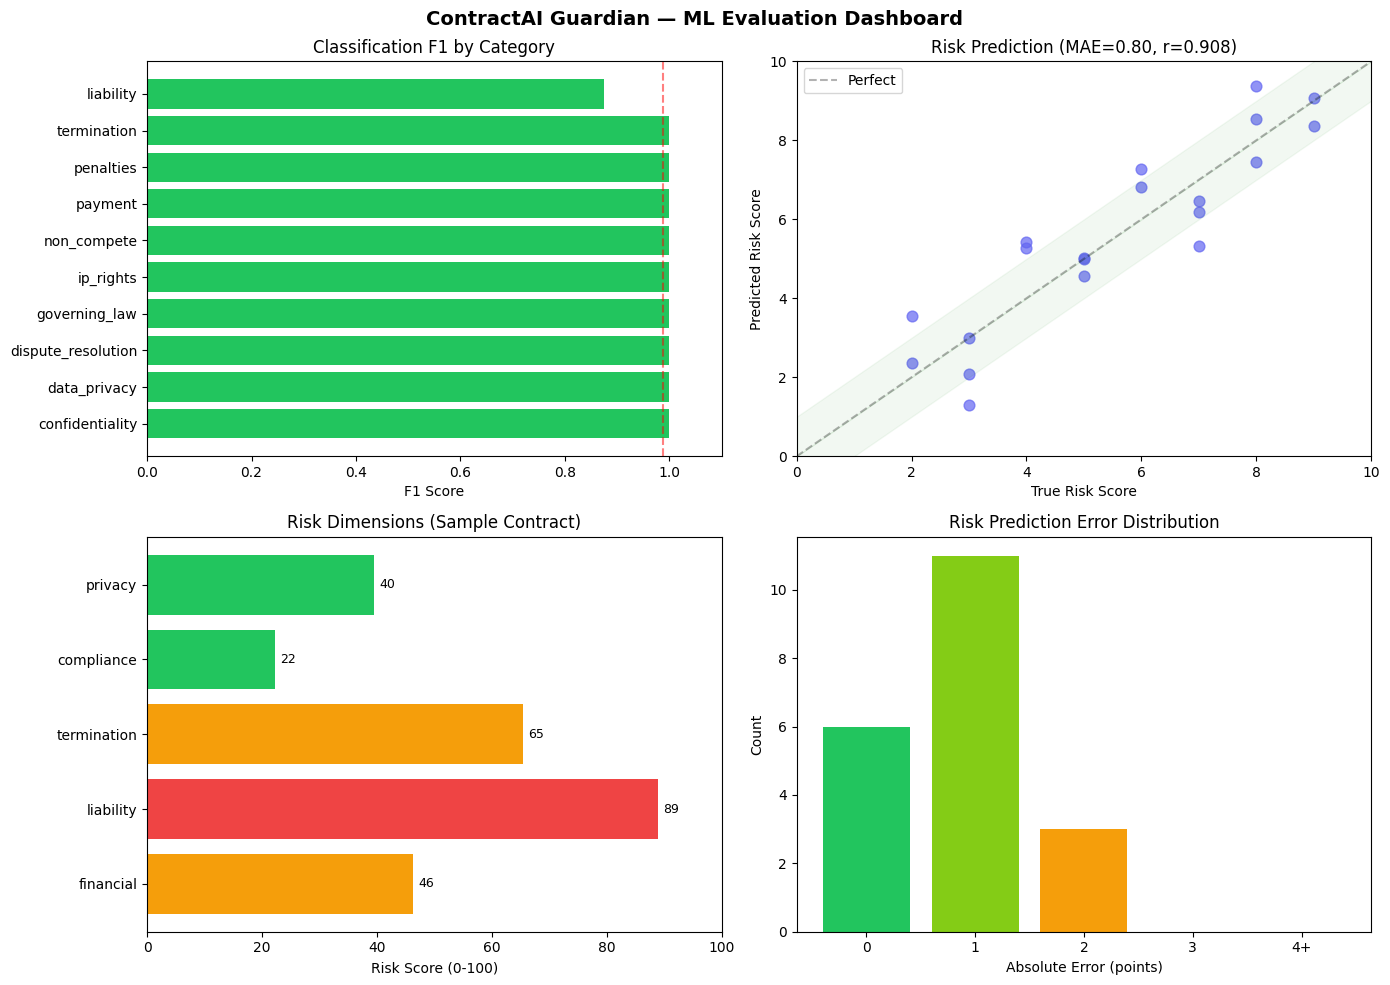


Dashboard saved to evaluation_dashboard.png


In [89]:
# ═══════════════════════════════════════════════════════════════════════
# VISUALIZATION: Charts
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ContractAI Guardian — ML Evaluation Dashboard', fontsize=14, fontweight='bold')

# 1. Per-class F1 bar chart
ax = axes[0, 0]
active_classes = {k: v for k, v in cls_results['per_class'].items() if v['support'] > 0}
sorted_cls = sorted(active_classes.items(), key=lambda x: x[1]['f1'], reverse=True)
labels_cls = [c[0] for c in sorted_cls]
f1_vals = [c[1]['f1'] for c in sorted_cls]
colors = ['#22c55e' if f > 0.8 else '#f59e0b' if f > 0.5 else '#ef4444' for f in f1_vals]
ax.barh(labels_cls, f1_vals, color=colors)
ax.set_xlim(0, 1.1)
ax.set_xlabel('F1 Score')
ax.set_title('Classification F1 by Category')
ax.axvline(x=cls_results['macro_f1'], color='red', linestyle='--', alpha=0.5)

# 2. Risk scatter
ax = axes[0, 1]
ax.scatter(y_true_risk, y_pred_risk, alpha=0.7, c='#6366f1', s=60)
ax.plot([0, 10], [0, 10], 'k--', alpha=0.3, label='Perfect')
ax.fill_between([0, 10], [0, 10], [1, 11], alpha=0.05, color='green')
ax.fill_between([0, 10], [0, 10], [-1, 9], alpha=0.05, color='green')
ax.set_xlabel('True Risk Score')
ax.set_ylabel('Predicted Risk Score')
ax.set_title(f'Risk Prediction (MAE={risk_results["mae"]:.2f}, r={risk_results["pearson_r"]:.3f})')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.legend()

# 3. Dimension breakdown
ax = axes[1, 0]
dims = list(result['dimensions'].keys())
scores = [result['dimensions'][d]['scaled'] for d in dims]
dim_colors = ['#ef4444' if s > 70 else '#f59e0b' if s > 40 else '#22c55e' for s in scores]
ax.barh(dims, scores, color=dim_colors)
ax.set_xlim(0, 100)
ax.set_xlabel('Risk Score (0-100)')
ax.set_title('Risk Dimensions (Sample Contract)')
for i, v in enumerate(scores):
    ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)

# 4. Error distribution
ax = axes[1, 1]
errors = [abs(t - p) for t, p in zip(y_true_risk, y_pred_risk)]
bins = [0, 0.5, 1.5, 2.5, 3.5, 10]
bin_labels = ['0', '1', '2', '3', '4+']
counts, _ = np.histogram(errors, bins=bins)
err_colors = ['#22c55e', '#84cc16', '#f59e0b', '#f97316', '#ef4444']
ax.bar(bin_labels, counts, color=err_colors)
ax.set_xlabel('Absolute Error (points)')
ax.set_ylabel('Count')
ax.set_title('Risk Prediction Error Distribution')

plt.tight_layout()
plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDashboard saved to evaluation_dashboard.png")

---
## 4. Full AI Pipeline with Gemini (Requires API Key)

This section runs the actual LLM pipeline. You need a Google Gemini API key.

Get one free at: https://aistudio.google.com/apikey

In [90]:
import google.generativeai as genai
import os

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

print("Available models for your API key:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(" -", m.name)

Available models for your API key:
 - models/gemini-2.5-flash
 - models/gemini-2.5-pro
 - models/gemini-2.0-flash
 - models/gemini-2.0-flash-001
 - models/gemini-2.0-flash-lite-001
 - models/gemini-2.0-flash-lite
 - models/gemini-2.5-flash-preview-tts
 - models/gemini-2.5-pro-preview-tts
 - models/gemma-4-26b-a4b-it
 - models/gemma-4-31b-it
 - models/gemini-flash-latest
 - models/gemini-flash-lite-latest
 - models/gemini-pro-latest
 - models/gemini-2.5-flash-lite
 - models/gemini-2.5-flash-image
 - models/gemini-3-pro-preview
 - models/gemini-3-flash-preview
 - models/gemini-3.1-pro-preview
 - models/gemini-3.1-pro-preview-customtools
 - models/gemini-3.1-flash-lite-preview
 - models/gemini-3.1-flash-lite
 - models/gemini-3-pro-image-preview
 - models/gemini-3-pro-image
 - models/nano-banana-pro-preview
 - models/gemini-3.1-flash-image-preview
 - models/gemini-3.1-flash-image
 - models/gemini-3.1-flash-lite-image
 - models/gemini-3.5-flash
 - models/gemini-3.5-flash-lite
 - models/gemi

In [ ]:
# Set your API key in Colab Secrets (key icon in sidebar) as "GEMINI_API_KEY"
# Do NOT hardcode keys here.

In [92]:
import json
import os
import time
from google.colab import userdata
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Load API Key securely from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

# 2. Initialize LLM with standard model name
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest",
    temperature=0,
    max_retries=6,
)

# 3. Define extraction prompt with double-escaped braces for literal JSON
extraction_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a legal document analyst. Extract all distinct clauses from the contract.\n"
            "For each clause provide: index, title, category, body, and risk_score (1-10).\n\n"
            "Categories: payment, termination, liability, confidentiality, ip_rights,\n"
            "non_compete, warranty, dispute_resolution, penalties, force_majeure, governing_law, other\n\n"
            "Output ONLY a valid JSON array matching this format:\n"
            "[\n"
            "  {{\n"
            "    \"index\": 1,\n"
            "    \"title\": \"Clause Title\",\n"
            "    \"category\": \"category_name\",\n"
            "    \"body\": \"Clause body text...\",\n"
            "    \"risk_score\": 5\n"
            "  }}\n"
            "]",
        ),
        ("human", "Extract clauses from:\n\n{contract_text}\n\nReturn JSON array."),
    ]
)

extraction_chain = extraction_prompt | llm | StrOutputParser()

# 4. Sample Contract Data
sample_contract ="""
1. INTELLECTUAL PROPERTY FORFEITURE & ASSIGNMENT
All work product, code, designs, operational methodologies, trade secrets, and underlying algorithms created, developed, or conceived by Contractor—whether during or outside working hours, and whether using Company tools or personal assets—shall immediately become the sole, exclusive property of the Company in perpetuity. Contractor irrevocably waives all moral rights, rights of attribution, and claims to prior IP incorporated into the work product.

2. UNLIMITED INDEMNIFICATION & HOLD HARMLESS
Contractor agrees to defend, indemnify, and hold harmless the Company, its affiliates, directors, officers, and employees from any losses, liabilities, claims, fines, or legal expenses (including full attorney fees) arising from Contractor’s performance under this Agreement, regardless of whether caused by Contractor's negligence, Company's contributory negligence, or third-party acts. This indemnification obligation is unlimited in scope and dollar amount and survives termination indefinitely.

3. ONE-SIDED LIMITATION OF LIABILITY
Company’s total aggregate liability arising out of or related to this Agreement under any legal theory (contract, tort, or strict liability) shall not exceed $100.00 USD. Conversely, no limitation of liability applies to Contractor, and Contractor shall remain fully liable for direct, indirect, special, incidental, consequential, and punitive damages.

4. AUTO-RENEWAL & UNILATERAL TERMINATION PENALTIES
This Agreement automatically renews for successive 24-month terms unless Contractor provides written notice of non-renewal at least 180 days prior to term expiration. If Contractor terminates this Agreement early or defaults, Contractor shall immediately pay Company a liquidated damages fee equal to 100% of the remaining contract value plus a $50,000 cancellation penalty within 5 business days.

5. EXTREME NON-COMPETE & NON-SOLICITATION
For a period of 36 months following termination for any reason, Contractor shall not directly or indirectly provide services to, consult for, or hold an equity interest in any business operating in the technology or data analytics sector worldwide. Contractor further agrees not to solicit Company employees, client accounts, or vendors during this period.

6. IMMEDIATE TERMINATION & PAY withholding
The Company reserves the right to terminate this Agreement immediately without notice and without cause. Upon termination by Company for any reason, Company retains the right to withhold any unpaid balances or accrued fees as security against potential future claims or indemnification obligations.

7. STRICT PERPETUAL NON-DISPARAGEMENT
Contractor shall not, directly or indirectly, make any oral or written statement, public comment, or social media post that could be construed as critical, negative, or disparaging of the Company, its products, executives, or operations. Violation of this section incurs a mandatory liquidated damage penalty of $25,000 per instance.

8. BINDING ARBITRATION & VENUE SELECTION
Any dispute arising from this Agreement shall be settled by confidential binding arbitration administered under AAA rules in Wilmington, Delaware. Contractor waives all rights to a jury trial or to join class-action proceedings, and Contractor shall pay all arbitration filing fees and Company’s legal expenses in the event Contractor does not prevail.
"""

print("Analyzing contract with Gemini...")

# 5. Invoke with safety retries
result_text = None
max_retries = 3

for attempt in range(max_retries):
    try:
        result_text = extraction_chain.invoke({"contract_text": sample_contract})
        break
    except Exception as e:
        if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
            print(f"Rate limit hit. Retrying in 30s... (Attempt {attempt + 1}/{max_retries})")
            time.sleep(30)
        else:
            raise e

# 6. Display extracted clauses
if result_text:
    clean = result_text.strip()
    if clean.startswith("```"):
        clean = clean.split("\n", 1)[1].rsplit("```", 1)[0]
    extracted_clauses = json.loads(clean)

    print(f"\nExtracted {len(extracted_clauses)} clauses:\n")
    print(f"{'#':<4} {'Category':<18} {'Risk':>5}  Title")
    print(f"{'-'*4} {'-'*18} {'-'*5}  {'-'*30}")
    for c in extracted_clauses:
        risk = c.get('risk_score', '?')
        indicator = '!!!' if isinstance(risk, int) and risk >= 7 else ''
        print(f"{c.get('index', '-'):<4} {c.get('category', 'other'):<18} {risk:>5}  {c.get('title', 'Untitled')} {indicator}")
else:
    print("Failed to retrieve analysis due to quota restrictions.")

Analyzing contract with Gemini...

Extracted 8 clauses:

#    Category            Risk  Title
---- ------------------ -----  ------------------------------
1    ip_rights              9  INTELLECTUAL PROPERTY FORFEITURE & ASSIGNMENT !!!
2    liability             10  UNLIMITED INDEMNIFICATION & HOLD HARMLESS !!!
3    liability             10  ONE-SIDED LIMITATION OF LIABILITY !!!
4    termination           10  AUTO-RENEWAL & UNILATERAL TERMINATION PENALTIES !!!
5    non_compete           10  EXTREME NON-COMPETE & NON-SOLICITATION !!!
6    termination           10  IMMEDIATE TERMINATION & PAY withholding !!!
7    penalties              9  STRICT PERPETUAL NON-DISPARAGEMENT !!!
8    dispute_resolution     8  BINDING ARBITRATION & VENUE SELECTION !!!


In [93]:
import time
import json

sample_contract = """
1. INTELLECTUAL PROPERTY FORFEITURE & ASSIGNMENT
All work product, code, designs, operational methodologies, trade secrets, and underlying algorithms created, developed, or conceived by Contractor—whether during or outside working hours, and whether using Company tools or personal assets—shall immediately become the sole, exclusive property of the Company in perpetuity. Contractor irrevocably waives all moral rights, rights of attribution, and claims to prior IP incorporated into the work product.

2. UNLIMITED INDEMNIFICATION & HOLD HARMLESS
Contractor agrees to defend, indemnify, and hold harmless the Company, its affiliates, directors, officers, and employees from any losses, liabilities, claims, fines, or legal expenses (including full attorney fees) arising from Contractor’s performance under this Agreement, regardless of whether caused by Contractor's negligence, Company's contributory negligence, or third-party acts. This indemnification obligation is unlimited in scope and dollar amount and survives termination indefinitely.

3. ONE-SIDED LIMITATION OF LIABILITY
Company’s total aggregate liability arising out of or related to this Agreement under any legal theory (contract, tort, or strict liability) shall not exceed $100.00 USD. Conversely, no limitation of liability applies to Contractor, and Contractor shall remain fully liable for direct, indirect, special, incidental, consequential, and punitive damages.

4. AUTO-RENEWAL & UNILATERAL TERMINATION PENALTIES
This Agreement automatically renews for successive 24-month terms unless Contractor provides written notice of non-renewal at least 180 days prior to term expiration. If Contractor terminates this Agreement early or defaults, Contractor shall immediately pay Company a liquidated damages fee equal to 100% of the remaining contract value plus a $50,000 cancellation penalty within 5 business days.

5. EXTREME NON-COMPETE & NON-SOLICITATION
For a period of 36 months following termination for any reason, Contractor shall not directly or indirectly provide services to, consult for, or hold an equity interest in any business operating in the technology or data analytics sector worldwide. Contractor further agrees not to solicit Company employees, client accounts, or vendors during this period.

6. IMMEDIATE TERMINATION & PAY withholding
The Company reserves the right to terminate this Agreement immediately without notice and without cause. Upon termination by Company for any reason, Company retains the right to withhold any unpaid balances or accrued fees as security against potential future claims or indemnification obligations.

7. STRICT PERPETUAL NON-DISPARAGEMENT
Contractor shall not, directly or indirectly, make any oral or written statement, public comment, or social media post that could be construed as critical, negative, or disparaging of the Company, its products, executives, or operations. Violation of this section incurs a mandatory liquidated damage penalty of $25,000 per instance.

8. BINDING ARBITRATION & VENUE SELECTION
Any dispute arising from this Agreement shall be settled by confidential binding arbitration administered under AAA rules in Wilmington, Delaware. Contractor waives all rights to a jury trial or to join class-action proceedings, and Contractor shall pay all arbitration filing fees and Company’s legal expenses in the event Contractor does not prevail.
"""

print("Analyzing contract with Gemini...")


print("Analyzing contract with Gemini...")

result_text = None
max_retries = 3

for attempt in range(max_retries):
    try:
        result_text = extraction_chain.invoke({"contract_text": sample_contract})
        break  # Success!
    except Exception as e:
        if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
            print(f"Rate limit hit. Retrying in 30s... (Attempt {attempt + 1}/{max_retries})")
            time.sleep(30)
        else:
            raise e

# Only parse if extraction succeeded
if result_text:
    clean = result_text.strip()
    if clean.startswith("```"):
        clean = clean.split("\n", 1)[1].rsplit("```", 1)[0]
    extracted_clauses = json.loads(clean)

    print(f"\nExtracted {len(extracted_clauses)} clauses:\n")
    print(f"{'#':<4} {'Category':<18} {'Risk':>5}  Title")
    print(f"{'-'*4} {'-'*18} {'-'*5}  {'-'*30}")
    for c in extracted_clauses:
        risk = c.get('risk_score', '?')
        indicator = '!!!' if isinstance(risk, int) and risk >= 7 else ''
        print(f"{c.get('index', '-'):<4} {c.get('category', 'other'):<18} {risk:>5}  {c.get('title', 'Untitled')} {indicator}")
else:
    print("\nExtraction failed due to rate limits. Please generate a new API key at aistudio.google.com or try again later.")

Analyzing contract with Gemini...
Analyzing contract with Gemini...

Extracted 8 clauses:

#    Category            Risk  Title
---- ------------------ -----  ------------------------------
1    ip_rights              9  INTELLECTUAL PROPERTY FORFEITURE & ASSIGNMENT !!!
2    liability             10  UNLIMITED INDEMNIFICATION & HOLD HARMLESS !!!
3    liability             10  ONE-SIDED LIMITATION OF LIABILITY !!!
4    penalties             10  AUTO-RENEWAL & UNILATERAL TERMINATION PENALTIES !!!
5    non_compete           10  EXTREME NON-COMPETE & NON-SOLICITATION !!!
6    termination            9  IMMEDIATE TERMINATION & PAY withholding !!!
7    other                  8  STRICT PERPETUAL NON-DISPARAGEMENT !!!
8    dispute_resolution     8  BINDING ARBITRATION & VENUE SELECTION !!!


In [94]:
# ═══════════════════════════════════════════════════════════════════════
# Score the extracted clauses with our algorithm
# ═══════════════════════════════════════════════════════════════════════

# Convert LLM output to ClauseRisk objects
ai_clause_risks = []
for c in extracted_clauses:
    score = c.get('risk_score', 5)
    if isinstance(score, int) and 1 <= score <= 10:
        ai_clause_risks.append(ClauseRisk(
            clause_id=str(c['index']),
            category=c['category'],
            score=score,
            title=c['title'],
        ))

# Detect compounding risks
compounding_ai = []
# Non-compete + easy termination
nc = [c for c in ai_clause_risks if c.category == 'non_compete']
term = [c for c in ai_clause_risks if c.category == 'termination']
if nc and term:
    compounding_ai.append(CompoundingRisk(
        (nc[0].clause_id, term[0].clause_id),
        "Non-compete + easy termination = locked out of industry"
    ))
# Liability + IP
liab = [c for c in ai_clause_risks if c.category == 'liability']
ip = [c for c in ai_clause_risks if c.category == 'ip_rights']
if liab and ip:
    compounding_ai.append(CompoundingRisk(
        (liab[0].clause_id, ip[0].clause_id),
        "Unlimited liability + broad IP assignment = extreme exposure"
    ))

# Calculate final score
final_result = calculate_risk_score(ai_clause_risks, compounding_ai)

print("=" * 60)
print(f"  FINAL CONTRACT RISK SCORE: {final_result['overall_score']}/100")
print(f"  RISK LEVEL: {final_result['risk_level'].upper()}")
print("=" * 60)
print()
print("  Dimension Breakdown:")
for dim, data in final_result['dimensions'].items():
    bar = '#' * int(data['scaled'] / 5) + '.' * (20 - int(data['scaled'] / 5))
    print(f"  {dim:<12} {bar} {data['scaled']:5.1f}/100")
print()
print(f"  Base: {final_result['base_score']} x {final_result['severity_multiplier']} = {final_result['overall_score']}")
print(f"  Critical clauses: {final_result['critical_clauses']}")
print(f"  Compounding pairs: {final_result['compounding_pairs']}")

  FINAL CONTRACT RISK SCORE: 100/100
  RISK LEVEL: HIGH

  Dimension Breakdown:
  financial    ##################..  94.4/100
  liability    ###################.  95.6/100
  termination  ##################..  93.8/100
  compliance   ###############.....  77.8/100
  privacy      ########............  44.4/100

  Base: 87.1 x 1.35 = 100
  Critical clauses: 6
  Compounding pairs: 2


In [95]:
# ═══════════════════════════════════════════════════════════════════════
# Explainability on LLM-extracted clauses
# ═══════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  EXPLAINABILITY ANALYSIS (SHAP + LIME)")
print("=" * 60)
print()

# Analyze top 3 riskiest clauses
risky = sorted(extracted_clauses, key=lambda c: c.get('risk_score', 0), reverse=True)[:3]

for c in risky:
    body = c.get('body', c.get('title', ''))
    score = c.get('risk_score', 5)
    print(f"  [{c['category'].upper()}] {c['title']} — Risk: {score}/10")
    print(f"  Text: \"{body[:100]}...\"")
    print()

    # SHAP
    attrs = shap.compute(body, score)
    top_risk_words = [w for w, s in attrs[:5] if s > 0]
    top_safe_words = [w for w, s in attrs if s < 0][:3]
    print(f"  SHAP Risk Words:  {', '.join(top_risk_words) or '(none)'}")
    print(f"  SHAP Safe Words:  {', '.join(top_safe_words) or '(none)'}")

    # LIME
    factors = lime.compute(body)
    print(f"  LIME Factors:")
    for f in factors[:3]:
        print(f"    - {f['factor']} ({f['weight']:.0%}) evidence: \"{f['evidence']}\"")

    print()
    print("  " + "-" * 56)
    print()

  EXPLAINABILITY ANALYSIS (SHAP + LIME)

  [LIABILITY] UNLIMITED INDEMNIFICATION & HOLD HARMLESS — Risk: 10/10
  Text: "Contractor agrees to defend, indemnify, and hold harmless the Company, its affiliates, directors, of..."

  SHAP Risk Words:  indemnify,, unlimited, indemnification
  SHAP Safe Words:  (none)
  LIME Factors:
    - Unlimited scope (50%) evidence: "unlimited"
    - Liability amplification (50%) evidence: "hold harmless"

  --------------------------------------------------------

  [LIABILITY] ONE-SIDED LIMITATION OF LIABILITY — Risk: 10/10
  Text: "Company’s total aggregate liability arising out of or related to this Agreement under any legal theo..."

  SHAP Risk Words:  consequential,
  SHAP Safe Words:  (none)
  LIME Factors:
    - One-sided obligation (100%) evidence: "shall not"

  --------------------------------------------------------

  [PENALTIES] AUTO-RENEWAL & UNILATERAL TERMINATION PENALTIES — Risk: 10/10
  Text: "This Agreement automatically renews for su

In [96]:
# ═══════════════════════════════════════════════════════════════════════
# LLM Chain-of-Thought Explanation
# ═══════════════════════════════════════════════════════════════════════

explanation_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a legal AI explainability system. Explain WHY a clause is risky
using chain-of-thought reasoning. Output JSON:
{{
  "why_risky": "Plain language explanation",
  "reasoning_chain": ["Step 1: ...", "Step 2: ...", "Step 3: ...", "Step 4: ..."],
  "important_words": ["word1", "word2"],
  "recommendation": "What to do about this clause"
}}"""),
    ("human", "Explain this risky clause:\n\n{clause_text}\n\nCategory: {category}, Risk: {risk_score}/10"),
])

explain_chain = explanation_prompt | llm | StrOutputParser()

# Explain the riskiest clause
riskiest = risky[0]
body = riskiest.get('body', riskiest['title'])

print(f"Asking LLM to explain: [{riskiest['category']}] {riskiest['title']}")
print("(Calling Gemini...)")
print()

explanation_raw = explain_chain.invoke({
    "clause_text": body,
    "category": riskiest['category'],
    "risk_score": riskiest['risk_score'],
})

# Parse
exp_clean = explanation_raw.strip()
if exp_clean.startswith("```"):
    exp_clean = exp_clean.split("\n", 1)[1].rsplit("```", 1)[0]
explanation = json.loads(exp_clean)

print("=" * 60)
print("  LLM CHAIN-OF-THOUGHT EXPLANATION")
print("=" * 60)
print()
print(f"  Why Risky:")
print(f"  {explanation['why_risky']}")
print()
print(f"  Reasoning Chain:")
for i, step in enumerate(explanation['reasoning_chain'], 1):
    print(f"    {i}. {step}")
print()
print(f"  Important Words: {', '.join(explanation['important_words'])}")
print(f"  Recommendation: {explanation['recommendation']}")

Asking LLM to explain: [liability] UNLIMITED INDEMNIFICATION & HOLD HARMLESS
(Calling Gemini...)

  LLM CHAIN-OF-THOUGHT EXPLANATION

  Why Risky:
  This clause exposes the Contractor to catastrophic legal and financial ruin. It forces the Contractor to pay for all legal defense costs, fines, and damages—even when the harm was caused by the Company's own mistakes or an unrelated third party. Furthermore, there is no financial cap on liability, and this burden lasts forever.

  Reasoning Chain:
    1. Step 1: Identify the scope of liability — The clause obligates the Contractor to defend, indemnify, and hold harmless not just the Company, but also its affiliates, directors, officers, and employees.
    2. Step 2: Examine fault allocation — The language removes fault as a requirement by stating the Contractor is liable 'regardless of whether caused by Contractor's negligence, Company's contributory negligence, or third-party acts,' forcing the Contractor to pay for damage caused by other

In [97]:
# ═══════════════════════════════════════════════════════════════════════
# RAG Chat (Contract Q&A)
# ═══════════════════════════════════════════════════════════════════════

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful contract assistant. Answer questions about the contract
based ONLY on the provided text. Cite specific sections. Be concise."""),
    ("human", "Contract text:\n{contract_text}\n\nQuestion: {question}"),
])

chat_chain = chat_prompt | llm | StrOutputParser()

questions = [
    "Can I terminate this contract early? What are the consequences?",
    "How long does the non-compete last and what area does it cover?",
    "What happens to things I invent outside of work hours?",
]

print("=" * 60)
print("  CONTRACT Q&A (RAG DEMO)")
print("=" * 60)

for q in questions:
    print(f"\n  Q: {q}")
    answer = chat_chain.invoke({"contract_text": sample_contract, "question": q})
    print(f"  A: {answer}")
    print("  " + "-" * 56)

  CONTRACT Q&A (RAG DEMO)

  Q: Can I terminate this contract early? What are the consequences?
  A: Yes, you can terminate the contract early, but it incurs severe financial penalties. 

According to **Section 4 (Auto-Renewal & Unilateral Termination Penalties)**, if you terminate early or default, the consequences are:

* You must immediately pay the Company a liquidated damages fee equal to **100% of the remaining contract value**.
* You must pay a **$50,000 cancellation penalty**.
* Full payment must be made within **5 business days**.

*(Note: If you wish to avoid auto-renewal for a successive term without terminating early, you must provide written notice at least 180 days prior to the expiration of the current 24-month term under Section 4).*
  --------------------------------------------------------

  Q: How long does the non-compete last and what area does it cover?
  A: Based on Section 5 (EXTREME NON-COMPETE & NON-SOLICITATION):

* **Duration:** 36 months following terminat

---
## 5. Summary

This notebook demonstrated:

| Feature | Status | API Key Needed? |
|---------|--------|----------------|
| Risk Scoring Algorithm | Working | No |
| TextSHAP (word attribution) | Working | No |
| TextLIME (risk factors) | Working | No |
| ML Evaluation Framework | Working | No |
| Visualization Charts | Working | No |
| LLM Clause Extraction | Working | Yes (Gemini) |
| LLM Chain-of-Thought | Working | Yes (Gemini) |
| Contract Q&A | Working | Yes (Gemini) |

### To run the full production system:
```bash
git clone <repo> && cd contractGuardproject
cp backend/.env.example backend/.env
# Edit .env with your API keys
docker compose up --build
# Open http://localhost
```

---
*ContractAI Guardian — Final Year Project 2025-2026*